# Test video: 国庆搜索结果的音频分析准备

这是一个随机搜索到的单条视频试验样本，用来验证音频分析流程；不能仅凭搜索词、标题或仪式内容预先判断其主题或性质。此 notebook 先记录样本、流程和需要安装/下载的工具，不会自动安装大型模型或权重。

- 搜索词：`国庆`
- 文件：[原始视频](../video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4)
- 用途：单视频流程试跑；不是有代表性的语料样本
- 注意：保留原视频；处理后的音频和结果写入独立目录，不覆盖源文件


## 分析步骤

1. 登记样本来源、获取日期、标题、时长、语言和允许使用范围；不要只记录搜索词，也要保存可复查的来源信息。
2. 检查文件与音轨（时长、采样率、声道、削波/静音）；完整试听并记下讲话、音乐/唱歌、掌声、人群声和场景变化的大致时间点。
3. 从视频提取未经增强的 WAV 副本，并保留原始混合音频。
4. 用 Demucs 生成 vocals 与 no_vocals（伴奏估计）两个 stem；三种版本都进入后续质量检查和特征提取。stem 是模型估计，不保证完美分离。
5. 用 Silero VAD 找候选语音区间；用一种中文 ASR 生成带时间戳的转写。抽查识别结果，特别检查专有名词、嘈杂和重叠语音；保留不确定项。
6. 按完整句子/话轮和停顿建立片段，必要时参考声音场景变化。为片段保存起止时间；混合语音/音乐或难以判断的片段标记为待复核，不直接删除。
7. 分开生成表示：BGE-M3 文本向量用于转写相似性；CLAP 或声学特征用于声音相似性；YAMNet/PANNs 可作为声音事件候选。先比较各自结果，暂不盲目拼接向量。
8. 人工听看片段、核对转写和上下文，记录反复出现的词句、可能主题、声音元素及不确定性。模型/聚类产生的是待核查线索，不是结论。
9. 单个视频只能探索视频内部相似片段，不能支持稳定的跨视频主题结论。需要跨视频发现主题时，再收集来源和抽样方法清楚的多条可比视频。


## 需要安装/下载的工具

先装最小必需项，再按分析需要选择模型；不要一次安装清单中的所有可选项。PyTorch 应按机器的 CPU/CUDA 环境从官方安装说明选择版本，避免不匹配的 wheel。

### 系统工具

- **FFmpeg**（`ffmpeg` 和 `ffprobe`）：读取视频信息、提取音轨。需要在系统 PATH 中可运行；Ubuntu 可用系统包管理器安装。不要在 notebook 里用 `sudo` 自动安装。

### 第一阶段：音频检查与基础特征（先安装）

Python 包：`librosa`、`soundfile`、`numpy`、`pandas`、`matplotlib`。这些用于读取/检查音频、基础声学特征和结果表格。项目已有 librosa 分析，可复用环境或依赖，不必重复安装另一套。

### 第二阶段：语音定位与转写（按需选择）

- **Silero VAD**：Python 包 `silero-vad`，需要兼容的 PyTorch；模型权重首次使用时取得。
- 中文 ASR 在小样本上比较后选**一个**：
  - **FunASR**：Python 包 `funasr`；按选定模型说明准备模型，部分模型从 ModelScope 下载。
  - **faster-whisper**：Python 包 `faster-whisper`；选定的 Whisper 模型首次使用时从 Hugging Face 下载。模型大小和运行速度/内存需求不同。

两套 ASR 不必同时装进最终环境。模型文件可能很大；先用短片段评估中文、口号/专有名词、背景音乐和现场噪声下的转写质量。

- **Demucs**：Python 包 `demucs`；首次使用时可能需要取得分离模型权重。下方 notebook 单元会调用 `htdemucs` 双 stem 模式，输出 vocals 和 no_vocals。

### 第三阶段：文本主题探索

- **BGE-M3**：模型权重（首次加载时下载；也可按 `FlagEmbedding` 项目说明安装 Python 包）。
- **BERTopic**：Python 包 `bertopic`；它的主题表示可搭配 embedding 使用，默认还会使用降维和聚类相关依赖。确认使用该方案后再安装。

### 安装命令示例（按阶段执行，不要一次全部运行）

在项目选定的 Python 环境中运行；若系统需要 CUDA，请先按 PyTorch 官方说明安装匹配版本，再安装 Silero VAD。ASR 两种方案只选一个作为主流程：

```bash
# 基础音频分析
python -m pip install librosa soundfile numpy pandas matplotlib

# 语音定位：先按你的 CPU/CUDA 环境安装 PyTorch，再安装
python -m pip install silero-vad

# 中文 ASR：选择其一，并在测试后固定版本
python -m pip install -U funasr modelscope
# 或
python -m pip install -U faster-whisper

# 文本向量与主题探索：需要时再装
python -m pip install -U FlagEmbedding bertopic
```

以上是安装包示例，不会自动下载全部模型。首次加载时再按所选模型下载权重；建议记录模型名称/版本和缓存来源。

### 可选：声音探索与可视化

- **CLAP**：如采用 LAION-CLAP，安装相应包/依赖并取得匹配的模型权重；可探索音频与声音描述的相似性。
- **YAMNet 或 PANNs（二选一先试）**：取得预训练权重和对应运行依赖，用于产生宽泛声音事件候选分数。
- **UMAP / HDBSCAN**：如果 BERTopic 默认流程之外需要单独控制降维/聚类，再安装 `umap-learn` / `hdbscan`。HDBSCAN 的“noise/outlier”是算法未归簇的样本，不代表音频里的噪声。
- **Label Studio**：可选人工标注界面；小规模试验也可以先用 CSV。
- **Demucs**：可选音源分离工具；只有讲话与音乐确实重叠、且分离结果对问题有帮助时才试。保留原音频并检查分离伪影。

预训练权重通常会在模型第一次加载时自动下载，但也可按模型文档预先缓存。下载前核对模型许可证、来源、语言支持、所需存储/显存和数据处理条件。此项目目前未安装或接入上面列出的新工具；本 notebook 只是分阶段准备清单。


## 样本路径与输出约定

Notebook 的工作目录可能是项目根目录或 `notebooks/`，下面的代码会处理这两种常见情况。建议生成文件写入 `results/test_video/`：包括原始提取音频、Demucs stems、三种音频版本的质量摘要/波形图、分 stem 特征表、VAD/ASR 时间戳表和人工复核表。原始视频留在 `video/`，不要在处理步骤中覆盖它。


In [1]:
from pathlib import Path
import shutil
import subprocess

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

video_path = PROJECT_ROOT / "video" / "完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4"
output_dir = PROJECT_ROOT / "results" / "test_video"
output_dir.mkdir(parents=True, exist_ok=True)

if not video_path.is_file():
    raise FileNotFoundError(f"Test video not found: {video_path}")
for executable in ("ffmpeg", "ffprobe"):
    if shutil.which(executable) is None:
        raise FileNotFoundError(f"{executable} is required; install FFmpeg and ensure it is on PATH")

print("Video:", video_path)
print("Outputs:", output_dir)
subprocess.run(["ffprobe", "-hide_banner", "-i", str(video_path)], check=False)

Video: /home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4
Outputs: /home/ubuntu/music/results/test_video


Input #0, mov,mp4,m4a,3gp,3g2,mj2, from '/home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso2avc1mp41
    comment         : vid:v0d00fg10000dauoo1vog65ra61a526g
    encoder         : Lavf58.76.100
  Duration: 00:03:25.21, start: 0.000000, bitrate: 872 kb/s
  Stream #0:0(und): Video: h264 (High) (avc1 / 0x31637661), yuv420p(tv, bt709), 576x768 [SAR 1:1 DAR 3:4], 737 kb/s, 25 fps, 25 tbr, 12800 tbn, 50 tbc (default)
    Metadata:
      handler_name    : VideoHandler
      vendor_id       : [0][0][0][0]
  Stream #0:1(und): Audio: aac (LC) (mp4a / 0x6134706D), 44100 Hz, stereo, fltp, 128 kb/s (default)
    Metadata:
      handler_name    : SoundHandler
      vendor_id       : [0][0][0][0]


CompletedProcess(args=['ffprobe', '-hide_banner', '-i', '/home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4'], returncode=0)

## 提取分析用音频（手动运行）

先保存完整音轨的 WAV 副本，供试听和声学检查。ASR 如果要求单声道/16 kHz，再另建一份，不要把这份分析音频覆盖掉。该转换不等于降噪或内容清理。


In [2]:
audio_path = output_dir / "audio_original.wav"
subprocess.run([
    "ffmpeg", "-y", "-i", str(video_path), "-vn",
    "-c:a", "pcm_s16le", str(audio_path),
], check=True)
print(f"Extracted audio: {audio_path} ({audio_path.stat().st_size:,} bytes)")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Extracted audio: /home/ubuntu/music/results/test_video/audio_original.wav (36,200,572 bytes)


size=   35352kB time=00:03:25.19 bitrate=1411.4kbits/s speed= 586x    
video:0kB audio:35352kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.000343%


## 音源分离：保留三种输入版本（手动运行）

后续分析比较：①原始混合音频（`original_mix`），②Demucs `vocals` stem，③Demucs `no_vocals` stem（伴奏/非 vocals 估计）。这里的 vocals 模型主要面向歌声；现场讲话可能落入任一 stem，分离也可能产生伪影。它们是三种分析视角，不是严格的“主声/背景”真值。因此保留原始混音，并对三种版本使用相同质量检查与特征提取流程。

需要 `demucs` 已安装（如未安装，可在当前 notebook kernel 用 `%pip install -U demucs` 安装后重启 kernel）。运行后检查输出的两条 WAV 是否存在并试听；若模型下载或分离报错，先停在这里排查，不要继续处理缺失的 stem。

之前只对原始混音运行过的质量检查/向量输出仍可保留作基线。更新后的完整比较需要从本节开始重跑，再运行下面对三种版本生效的质量检查与向量化单元。

In [5]:
import sys

demucs_dir = output_dir / "demucs"
subprocess.run([
    sys.executable, "-m", "demucs",
    "-n", "htdemucs",
    "--two-stems=vocals",
    "-o", str(demucs_dir),
    str(audio_path),
], check=True)

stem_dir = demucs_dir / "htdemucs" / audio_path.stem
stem_paths = {
    "original_mix": audio_path,
    "vocals": stem_dir / "vocals.wav",
    "no_vocals": stem_dir / "no_vocals.wav",
}
missing_stems = [str(path) for name, path in stem_paths.items() if not path.is_file()]
if missing_stems:
    raise FileNotFoundError("Expected audio version(s) not created: " + ", ".join(missing_stems))

for name, path in stem_paths.items():
    print(f"{name}: {path} ({path.stat().st_size:,} bytes)")

Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /home/ubuntu/music/results/test_video/demucs/htdemucs
Separating track /home/ubuntu/music/results/test_video/audio_original.wav


100%|████████████████████████████████████████████████████████████████████████| 210.6/210.6 [00:07<00:00, 27.71seconds/s]


original_mix: /home/ubuntu/music/results/test_video/audio_original.wav (36,200,572 bytes)
vocals: /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/vocals.wav (36,200,492 bytes)
no_vocals: /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/no_vocals.wav (36,200,492 bytes)


## 生成音频 manifest（运行 stem 单元后）

Manifest 为同一视频的原始混音、vocals 和 no_vocals 各记录一行，包含相对路径、来源/搜索词、父文件、Demucs 配置、音频格式、时长、文件大小和 SHA-256。`source_url` 和 `retrieved_at_utc` 当前未知，留空待补。CSV 可作为未来批处理的输入清单：批处理脚本可逐行读取音频路径和版本元数据，为多个视频一致地运行相同步骤，并将结果关联回来源视频/stem；它本身不会自动运行处理。若重新提取或分离，重新运行此单元以更新路径元数据。

In [ ]:
from datetime import datetime, timezone
from hashlib import sha256
from importlib.metadata import version

def file_sha256(path, chunk_size=1024 * 1024):
    digest = sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

video_sha256 = file_sha256(video_path)
video_id = video_sha256[:16]
manifest_generated_at = datetime.now(timezone.utc).isoformat()
demucs_version = version("demucs")
manifest_rows = []

for stem_name, stem_path in stem_paths.items():
    info = sf.info(stem_path)
    is_original = stem_name == "original_mix"
    manifest_rows.append({
        "video_id": video_id,
        "title": video_path.stem,
        "source_url": "",
        "search_query": "国庆",
        "retrieved_at_utc": "",
        "manifest_generated_at_utc": manifest_generated_at,
        "video_path": str(video_path.relative_to(PROJECT_ROOT)),
        "video_sha256": video_sha256,
        "audio_variant": stem_name,
        "audio_path": str(stem_path.relative_to(PROJECT_ROOT)),
        "parent_audio_path": "" if is_original else str(audio_path.relative_to(PROJECT_ROOT)),
        "separation_model": "" if is_original else "htdemucs",
        "separation_target": "" if is_original else "vocals",
        "separation_parameters": "" if is_original else "--two-stems=vocals",
        "demucs_version": demucs_version if not is_original else "",
        "duration_seconds": float(info.duration),
        "sample_rate_hz": int(info.samplerate),
        "channels": int(info.channels),
        "audio_file_size_bytes": int(stem_path.stat().st_size),
        "audio_sha256": file_sha256(stem_path),
        "feature_window_seconds": 5.0,
        "feature_hop_seconds": 2.5,
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = output_dir / "audio_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print(f"Saved {len(manifest_df)} audio records to {manifest_path}")
print(manifest_df[["video_id", "audio_variant", "audio_path", "duration_seconds", "sample_rate_hz", "channels"]].to_string(index=False))

## 音频质量检查（三种版本分别检查）

这里做的是**技术质量筛查**：检查文件是否可读、时长/采样信息、削波、近静音比例和 RMS 电平，并画出波形。它不能自动判断内容是否重要，也不能仅凭这些指标可靠地区分背景声和有意义的声音。没有单独的噪声参考段时，不应把 RMS 当作 SNR；建议结合试听和时间戳备注。

需要第一阶段依赖：`librosa`、`soundfile`、`numpy`、`pandas`、`matplotlib`。运行后会为原始混音、vocals、no_vocals 分别保存质量摘要和波形图。

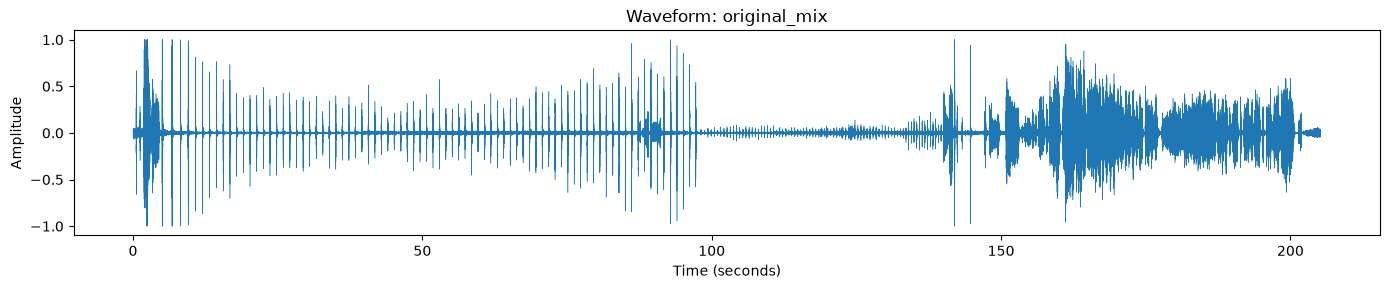

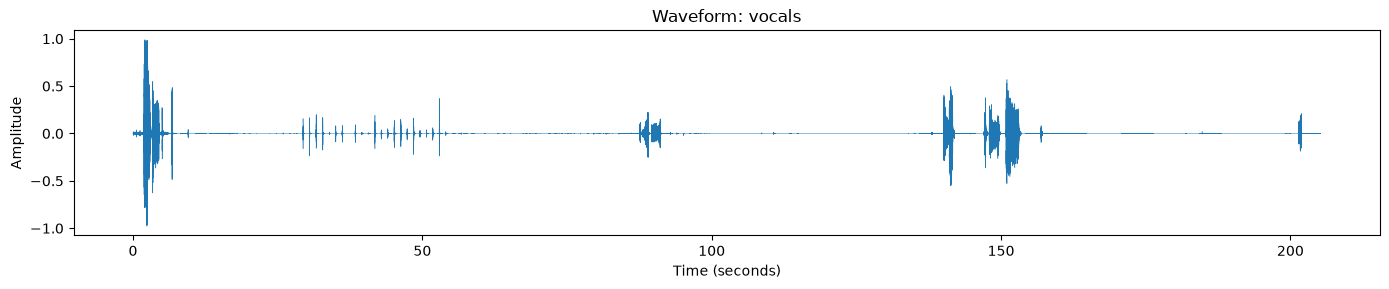

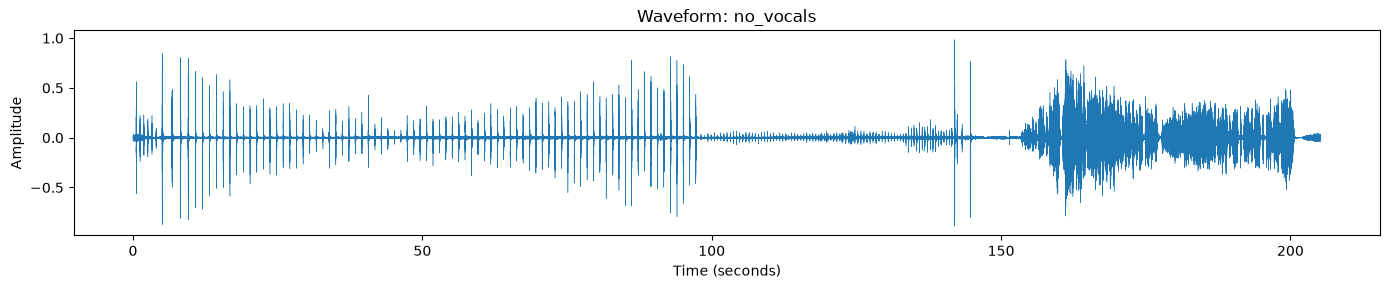

,stem,file,duration_seconds,sample_rate_hz,channels,frames,peak_absolute_amplitude,clipped_sample_fraction,rms_mean,near_silence_frame_fraction,near_silence_rms_threshold
0,original_mix,results/test_video/audio_original.wav,205.217959,44100,2,9050112,1.000000,0.000018,0.069106,0.000000,0.0001
1,vocals,results/test_video/demucs/htdemucs/audio_origi...,205.217959,44100,2,9050112,0.989960,0.000000,0.034986,0.644057,0.0001
2,no_vocals,results/test_video/demucs/htdemucs/audio_origi...,205.217959,44100,2,9050112,0.984711,0.000000,0.047825,0.000000,0.0001


In [6]:
import json
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_variants = {}
quality_rows = []
silence_threshold = 1e-4

for stem_name, stem_path in stem_paths.items():
    audio_info = sf.info(stem_path)
    y, sr = librosa.load(stem_path, sr=None, mono=True)
    duration_s = len(y) / sr
    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    frame_rms = librosa.feature.rms(y=y)[0]
    silence_fraction = float(np.mean(frame_rms < silence_threshold)) if len(frame_rms) else 0.0
    quality = {
        "stem": stem_name,
        "file": str(stem_path.relative_to(PROJECT_ROOT)),
        "duration_seconds": duration_s,
        "sample_rate_hz": int(audio_info.samplerate),
        "channels": int(audio_info.channels),
        "frames": int(audio_info.frames),
        "peak_absolute_amplitude": peak,
        "clipped_sample_fraction": float(np.mean(np.abs(y) >= 0.999)) if len(y) else 0.0,
        "rms_mean": float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0,
        "near_silence_frame_fraction": silence_fraction,
        "near_silence_rms_threshold": silence_threshold,
    }
    (output_dir / f"audio_quality_{stem_name}.json").write_text(
        json.dumps(quality, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    time = np.arange(len(y)) / sr
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(time, y, linewidth=0.35)
    ax.set(xlabel="Time (seconds)", ylabel="Amplitude", title=f"Waveform: {stem_name}")
    fig.tight_layout()
    fig.savefig(output_dir / f"audio_waveform_{stem_name}.png", dpi=150)
    plt.show()
    audio_variants[stem_name] = {"path": stem_path, "y": y, "sr": sr, "duration_s": duration_s}
    quality_rows.append(quality)

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

## 基础向量化：三种音频版本分别计算

下面对原始混音、vocals、no_vocals 分别用 5 秒窗口、2.5 秒步长提取同一组可解释的声学特征：MFCC 的均值/标准差、12 维 chroma，以及 RMS、谱质心、谱带宽、谱滚降、过零率和谱对比度的统计量。每行带有 stem 名称和片段起止时间，分别保存 CSV，并合并保存一份总表便于后续比较。

这只是**手工声学特征向量**，不是 CLAP 等预训练模型 embedding，也不代表主题/宣传标签。固定窗口适合先跑通流程；之后可把窗口替换为 VAD 或句子时间戳。短于 0.5 秒的尾段跳过，避免极短窗口导致特征不稳定。

该视频单独生成的向量只能描述本片段；要做跨视频相似性/聚类，需要对所有视频使用完全一致的特征和窗口策略。标准化参数应在整个比较语料上拟合，不要针对每个窗口单独标准化。三种版本的时间边界/时长若有微小差异，按各自实际音频长度记录。

In [7]:
window_seconds = 5.0
hop_seconds = 2.5
min_tail_seconds = 0.5
all_feature_frames = []

def summarize_feature(name, values, row):
    values = np.asarray(values, dtype=float)
    row[f"{name}_mean"] = float(np.mean(values))
    row[f"{name}_std"] = float(np.std(values))

for stem_name, variant in audio_variants.items():
    y = variant["y"]
    sr = variant["sr"]
    duration_s = variant["duration_s"]
    feature_rows = []
    for start_s in np.arange(0.0, duration_s, hop_seconds):
        end_s = min(start_s + window_seconds, duration_s)
        if end_s - start_s < min_tail_seconds:
            continue
        start_sample = int(round(start_s * sr))
        end_sample = min(int(round(end_s * sr)), len(y))
        segment = y[start_sample:end_sample]
        if len(segment) == 0:
            continue

        row = {"stem": stem_name, "start_seconds": float(start_s), "end_seconds": float(end_s)}
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13)
        for i in range(mfcc.shape[0]):
            row[f"mfcc_{i + 1}_mean"] = float(np.mean(mfcc[i]))
            row[f"mfcc_{i + 1}_std"] = float(np.std(mfcc[i]))

        chroma = librosa.feature.chroma_stft(y=segment, sr=sr)
        for i in range(chroma.shape[0]):
            row[f"chroma_{i}"] = float(np.mean(chroma[i]))

        summarize_feature("rms", librosa.feature.rms(y=segment)[0], row)
        summarize_feature("spectral_centroid", librosa.feature.spectral_centroid(y=segment, sr=sr)[0], row)
        summarize_feature("spectral_bandwidth", librosa.feature.spectral_bandwidth(y=segment, sr=sr)[0], row)
        summarize_feature("spectral_rolloff", librosa.feature.spectral_rolloff(y=segment, sr=sr)[0], row)
        summarize_feature("zero_crossing_rate", librosa.feature.zero_crossing_rate(y=segment)[0], row)
        contrast = librosa.feature.spectral_contrast(y=segment, sr=sr)
        for i in range(contrast.shape[0]):
            row[f"spectral_contrast_{i}_mean"] = float(np.mean(contrast[i]))
            row[f"spectral_contrast_{i}_std"] = float(np.std(contrast[i]))
        feature_rows.append(row)

    stem_df = pd.DataFrame(feature_rows)
    stem_feature_path = output_dir / f"handcrafted_audio_vectors_{stem_name}.csv"
    stem_df.to_csv(stem_feature_path, index=False)
    all_feature_frames.append(stem_df)
    print(f"{stem_name}: {len(stem_df)} windows x {stem_df.shape[1] - 3} features -> {stem_feature_path}")

feature_df = pd.concat(all_feature_frames, ignore_index=True)
combined_feature_path = output_dir / "handcrafted_audio_vectors_all_stems.csv"
feature_df.to_csv(combined_feature_path, index=False)
print("Combined rows:", len(feature_df))
print("Feature dimensions (excluding stem and timestamps):", feature_df.shape[1] - 3)
print("Saved combined table:", combined_feature_path)
print(feature_df.groupby("stem").size())
print(feature_df.head().to_string(index=False))

original_mix: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_original_mix.csv
vocals: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_vocals.csv
no_vocals: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_no_vocals.csv
Combined rows: 246
Feature dimensions (excluding stem and timestamps): 62
Saved combined table: /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_all_stems.csv
stem
no_vocals       82
original_mix    82
vocals          82
dtype: int64
        stem  start_seconds  end_seconds  mfcc_1_mean  mfcc_1_std  mfcc_2_mean  mfcc_2_std  mfcc_3_mean  mfcc_3_std  mfcc_4_mean  mfcc_4_std  mfcc_5_mean  mfcc_5_std  mfcc_6_mean  mfcc_6_std  mfcc_7_mean  mfcc_7_std  mfcc_8_mean  mfcc_8_std  mfcc_9_mean  mfcc_9_std  mfcc_10_mean  mfcc_10_std  mfcc_11_mean  mfcc_11_std  mfcc_12_mean  mfcc_12_std  mfcc_13_mean  mfcc_13_std  chroma_0  chroma_1  chrom

## 预训练 embedding 与后续主题分析（下一步，不在此处自动下载）

上面的 CSV 是可解释的手工特征。预训练音频 embedding（例如 CLAP）需要选择模型、匹配其输入采样率/时长并下载对应权重；中文 ASR 转写后可用 BGE-M3 产生**文本** embedding。建议先在人工试听/核对过的若干片段上测试一条音频向量路线和一条文本向量路线，分开保存与比较，再考虑聚类。

文本主题可尝试 BERTopic；音频或文本向量的探索性分组可尝试 HDBSCAN。单个视频或少量窗口只适合试验代码和人工检查，不能据此声称已发现稳定的跨视频主题。注意 HDBSCAN 的 outlier/noise 指聚类算法未归类的向量，不是录音噪声。

## 分析记录表建议字段

`video_id`, `source`, `search_query`, `retrieved_at`, `stem` (`original_mix` / `vocals` / `no_vocals`), `start_time`, `end_time`, `transcript`, `asr_model`, `asr_confidence`, `vad_speech_probability`, `sound_event_candidates`, `text_embedding_path`, `audio_embedding_path`, `quality_flags`, `human_notes`, `uncertainty`。

本样本搜索词记录为 `国庆`。发现样本的搜索条件本身会影响语料，因此后续要同时记录其他搜索词/来源和纳入规则，避免把搜索结果误当作平台整体内容的代表。